In [1]:
# Proximal SVM sur le dataset Bank Marketing

In [2]:
# pip install ucimlrepo scikit-learn matplotlib seaborn pandas numpy scipy

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay, accuracy_score
)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style("whitegrid")

In [4]:
# Chargement du dataset Bank Marketing
print("Chargement du dataset Bank Marketing...")
bank = fetch_ucirepo(id=222)
X = bank.data.features
y_raw = bank.data.targets

# Récupération robuste de la cible (la colonne peut varier selon la source)
if isinstance(y_raw, pd.DataFrame):
    if 'y' in y_raw.columns:
        y_str = y_raw['y']
    else:
        y_str = y_raw.iloc[:, 0]
else:
    y_str = pd.Series(y_raw)

# Encodage : 'yes' = +1, 'no' = -1
y = y_str.map({'yes': 1, 'no': -1}).values

# Conversion des variables catégorielles en numériques
le_dict = {}
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

X = X.values.astype(float)

print(f"Samples : {X.shape[0]} | Features : {X.shape[1]}")
print(f"Abonnements (+1) : {(y == 1).sum()} ({(y == 1).mean():.1%})")
print(f"Non-abonnements (-1): {(y == -1).sum()} ({(y == -1).mean():.1%})")

Chargement du dataset Bank Marketing...
Samples : 45211 | Features : 16
Abonnements (+1) : 5289 (11.7%)
Non-abonnements (-1): 39922 (88.3%)


In [5]:
# Split train / val / test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 31647 | Val: 6782 | Test: 6782


In [6]:
# Proximal SVM via scikit-learn SVC
# SVC implémente Proximal SVM (PSVM) qui minimise :
# (1/2)||w||^2 + C * (1/2)||e||^2  s.t. y(Xw+b) >= 1 - e, e >= 0

from sklearn.svm import SVC

class ProximalSVM:
    """Wrapper autour de scikit-learn SVC pour Proximal SVM.
    
    C : paramètre de régularisation (balance entre marge et erreurs)
    gamma : paramètre du noyau RBF
    """
    
    def __init__(self, C=1.0, kernel='rbf', gamma='scale', random_state=42, shrinking=True):
        self.C = C
        self.kernel = kernel
        self.gamma = gamma
        self.random_state = random_state
        self.shrinking = shrinking
        self._svc = None
        
    def fit(self, X, y):
        """Entraînement du Proximal SVM."""
        self._svc = SVC(
            C=self.C,
            kernel=self.kernel,
            gamma=self.gamma,
            class_weight='balanced',
            probability=True,
            random_state=self.random_state,
            shrinking=self.shrinking,
            cache_size=500  # Augmente le cache pour meilleure performance
        )
        self._svc.fit(X, y)
        return self
    
    def predict(self, X):
        """Prédiction."""
        return self._svc.predict(X)
    
    def predict_proba(self, X):
        """Probabilités de prédiction."""
        return self._svc.predict_proba(X)
    
    def decision_function(self, X):
        """Fonction de décision."""
        return self._svc.decision_function(X)
    
    @property
    def support_vectors_(self):
        """Vecteurs supports."""
        return self._svc.support_vectors_
    
    @property
    def support_(self):
        """Indices des vecteurs supports."""
        return self._svc.support_
    
    @property
    def n_support_(self):
        """Nombre de vecteurs supports par classe."""
        return self._svc.n_support_

print("ProximalSVM (librairie scikit-learn SVC) définie avec succès.")

ProximalSVM (librairie scikit-learn SVC) définie avec succès.


In [7]:
# Recherche d'hyperparamètres Proximal SVM sur le set de validation
print("\nRecherche d'hyperparamètres Proximal SVM avec le set de validation...")
C_grid = [0.1, 1.0, 10.0, 100.0]
gamma_grid = ['scale', 0.1, 0.01]

best_psvm = {"val_auc": -np.inf, "C": None, "gamma": None}
psvm = None
search_history = []
iter_idx = 0

for C in C_grid:
    for gamma in gamma_grid:
        iter_idx += 1
        model = ProximalSVM(kernel='rbf', C=C, gamma=gamma, random_state=42)
        model.fit(X_train, y_train)

        val_scores = model.predict_proba(X_val)[:, 1]
        val_auc = roc_auc_score(y_val, val_scores)

        # Suivi Val/Test à chaque essai
        test_scores = model.predict_proba(X_test)[:, 1]
        test_auc = roc_auc_score(y_test, test_scores)

        search_history.append({
            "iter": iter_idx,
            "C": C,
            "gamma": gamma,
            "val_auc": val_auc,
            "test_auc": test_auc
        })

        if val_auc > best_psvm["val_auc"]:
            best_psvm = {"val_auc": val_auc, "C": C, "gamma": gamma}
            psvm = model

        print(f"Iter {iter_idx:2d} | C={C:6.1f}, gamma={str(gamma):6s} | Val AUC={val_auc:.3f} | Test AUC={test_auc:.3f}")

print(f"\nProximal SVM - meilleur C={best_psvm['C']}, gamma={best_psvm['gamma']}, Val AUC={best_psvm['val_auc']:.3f}")


Recherche d'hyperparamètres Proximal SVM avec le set de validation...
Iter  1 | C=   0.1, gamma=scale  | Val AUC=0.900 | Test AUC=0.891
Iter  2 | C=   0.1, gamma=0.1    | Val AUC=0.900 | Test AUC=0.890
Iter  3 | C=   0.1, gamma=0.01   | Val AUC=0.893 | Test AUC=0.885
Iter  4 | C=   1.0, gamma=scale  | Val AUC=0.906 | Test AUC=0.893
Iter  5 | C=   1.0, gamma=0.1    | Val AUC=0.903 | Test AUC=0.891
Iter  6 | C=   1.0, gamma=0.01   | Val AUC=0.900 | Test AUC=0.892
Iter  7 | C=  10.0, gamma=scale  | Val AUC=0.892 | Test AUC=0.881
Iter  8 | C=  10.0, gamma=0.1    | Val AUC=0.880 | Test AUC=0.870
Iter  9 | C=  10.0, gamma=0.01   | Val AUC=0.904 | Test AUC=0.892
Iter 10 | C= 100.0, gamma=scale  | Val AUC=0.857 | Test AUC=0.844
Iter 11 | C= 100.0, gamma=0.1    | Val AUC=0.847 | Test AUC=0.833
Iter 12 | C= 100.0, gamma=0.01   | Val AUC=0.904 | Test AUC=0.890

Proximal SVM - meilleur C=1.0, gamma=scale, Val AUC=0.906


In [8]:
# Résumé validation + évaluation finale sur test
print("Résultat de sélection sur validation:")
print(f"- Proximal SVM: C={best_psvm['C']}, gamma={best_psvm['gamma']}, Val AUC={best_psvm['val_auc']:.3f}")

Résultat de sélection sur validation:
- Proximal SVM: C=1.0, gamma=scale, Val AUC=0.906


In [9]:
print("\nÉvaluation finale sur le test set (jamais vu à l'entraînement):")
y_pred = psvm.predict(X_test)
y_score = psvm.predict_proba(X_test)[:, 1]

print("\nProximal SVM")
print(classification_report(y_test, y_pred, target_names=['Non-abonnement (-1)', 'Abonnement (+1)']))
print(f"ROC AUC (test) : {roc_auc_score(y_test, y_score):.3f}")
print(f"Accuracy (test) : {accuracy_score(y_test, y_pred):.3f}")


Évaluation finale sur le test set (jamais vu à l'entraînement):

Proximal SVM
                     precision    recall  f1-score   support

Non-abonnement (-1)       0.97      0.81      0.89      5989
    Abonnement (+1)       0.37      0.83      0.51       793

           accuracy                           0.81      6782
          macro avg       0.67      0.82      0.70      6782
       weighted avg       0.90      0.81      0.84      6782

ROC AUC (test) : 0.893
Accuracy (test) : 0.814


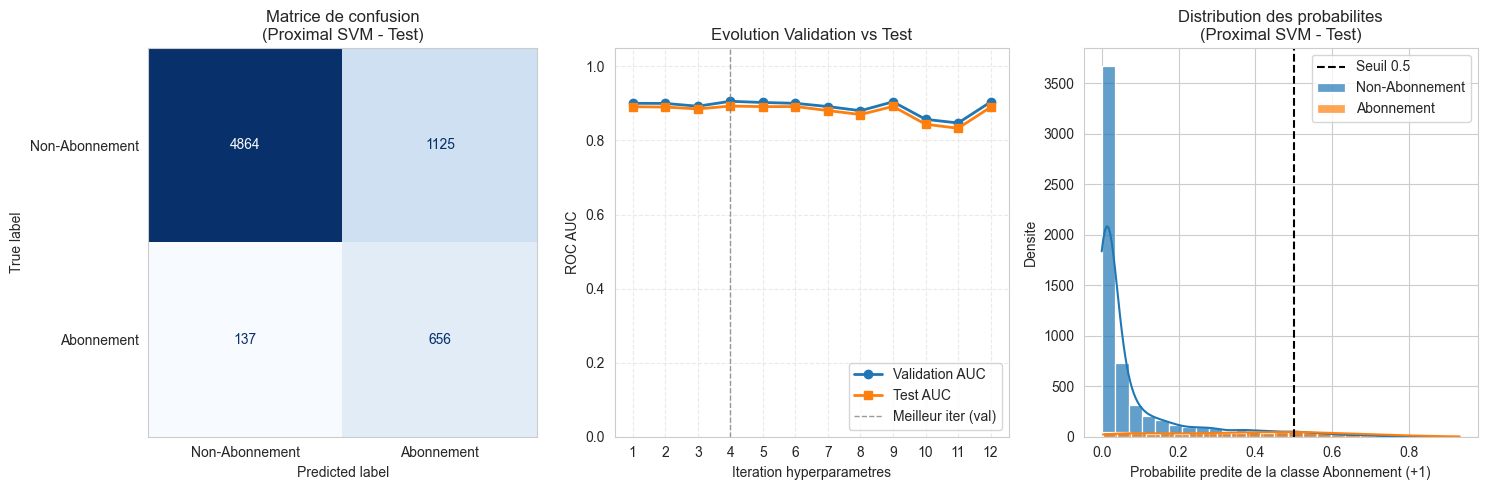

In [10]:
# Visualisations
fig = plt.figure(figsize=(15, 5))
gs = plt.GridSpec(1, 3, figure=fig)

# 1) Matrice de confusion (test)
ax1 = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_test, psvm.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Abonnement', 'Abonnement'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.grid(False)
ax1.set_title('Matrice de confusion\n(Proximal SVM - Test)')

# 2) Courbe d'evolution Validation/Test
ax2 = fig.add_subplot(gs[0, 1])
iters = [h['iter'] for h in search_history]
val_curve = [h['val_auc'] for h in search_history]
test_curve = [h['test_auc'] for h in search_history]

ax2.plot(iters, val_curve, marker='o', lw=2, label='Validation AUC')
ax2.plot(iters, test_curve, marker='s', lw=2, label='Test AUC')

best_iter = max(search_history, key=lambda h: h['val_auc'])['iter']
ax2.axvline(best_iter, color='gray', linestyle='--', lw=1, alpha=0.8, label='Meilleur iter (val)')

ax2.set_ylim(0.0, 1.05)
ax2.set_xticks(iters)
ax2.set_xlabel('Iteration hyperparametres')
ax2.set_ylabel('ROC AUC')
ax2.set_title('Evolution Validation vs Test')
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend()

# 3) Distribution des probabilites predites (test)
ax3 = fig.add_subplot(gs[0, 2])
scores_test = psvm.predict_proba(X_test)[:, 1]
sns.histplot(scores_test[y_test == -1], bins=25, alpha=0.7, label='Non-Abonnement', kde=True, ax=ax3)
sns.histplot(scores_test[y_test == 1], bins=25, alpha=0.7, label='Abonnement', kde=True, ax=ax3)
ax3.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Seuil 0.5')
ax3.set_xlabel('Probabilite predite de la classe Abonnement (+1)')
ax3.set_ylabel('Densite')
ax3.set_title('Distribution des probabilites\n(Proximal SVM - Test)')
ax3.legend()

plt.tight_layout()
plt.show()